# DSA 210 Term Project - Dive Log Analysis
## Aksel Ünlü

This notebook analyzes personal scuba dive logs recorded by a Suunto Ocean diving computer between July 2024 and January 2026. The goal is to investigate whether a significant inverse relationship exists between maximum dive depth and dive duration, motivated by the physiological constraints of nitrogen loading and decompression limits.

**Hypothesis:**
- H0: There is no significant relationship between maximum dive depth and dive duration.
- HA: Deeper dives have significantly shorter durations due to nitrogen loading and decompression constraints.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Load data
df = pd.read_csv("dives_parsed.csv")
df["duration_min"] = df["duration"] / 60
df["date"] = pd.to_datetime(df["date"])

print(f"Total dives loaded: {len(df)}")
df.head()

Total dives loaded: 118


,file,date,max_depth,duration,avg_temperature,min_temperature,duration_min
0,2024-07-12_10.36.18-scubadiving.fit,2024-07-12 10:36:18,16.910000,2159.30,23,NaN,35.988333
1,2024-07-12_13.09.34-scubadiving.fit,2024-07-12 13:09:34,6.210000,2631.12,24,NaN,43.852000
2,2024-07-13_12.03.07-scubadiving.fit,2024-07-13 12:03:07,5.440000,1579.31,23,NaN,26.321833
3,2024-07-13_13.53.12-scubadiving.fit,2024-07-13 13:53:12,17.969999,2186.99,23,NaN,36.449833
4,2024-07-14_09.14.38-scubadiving.fit,2024-07-14 09:14:38,33.430000,2472.62,22,NaN,41.210333


## Data Cleaning

33 out of 118 dives were identified as noise and removed. A dive is classified as noise if any of the following conditions are met:

1. Max depth < 5m (accidental logs or surface intervals)
2. Duration < 8 minutes (accidental triggers)
3. Max depth < 6m AND duration < 20 minutes (shallow training dives)

These thresholds were determined based on domain knowledge as a certified scuba diving instructor.

In [2]:
# --- Noise Filter ---
def is_noise(row):
    depth = row["max_depth"]
    duration = row["duration_min"]
    if depth < 5:
        return True
    if duration < 8:
        return True
    if depth < 6 and duration < 20:
        return True
    return False

df["noise"] = df.apply(is_noise, axis=1)
df_clean = df[df["noise"] == False].copy().reset_index(drop=True)

print(f"Total dives: {len(df)}")
print(f"Noise dives removed: {df['noise'].sum()}")
print(f"Clean dives remaining: {len(df_clean)}")
df_clean[["date", "max_depth", "duration_min"]].describe()

Total dives: 118
Noise dives removed: 33
Clean dives remaining: 85


,date,max_depth,duration_min
count,85,85.000000,85.000000
mean,2025-04-07 04:43:51.858823424,21.401177,42.534751
min,2024-07-12 10:36:18,5.060000,9.968333
25%,2024-10-26 12:40:01,17.270000,36.126333
50%,2025-05-02 09:44:35,19.219999,41.452667
75%,2025-10-04 14:10:49,28.950001,47.740667
max,2026-01-21 12:22:22,44.529999,78.778667
std,NaN,9.624829,10.301384


## Exploratory Data Analysis

We explore the distributions of the two key variables: maximum dive depth and dive duration, and visualize their relationship through a scatter plot.

Key observations from the summary statistics:
- Mean depth is 21.4m, ranging from 5.06m to 44.5m
- Mean duration is 42.5 minutes, ranging from 10 to 78.8 minutes
- The 20m threshold is close to the median depth, giving a reasonable split for hypothesis testing

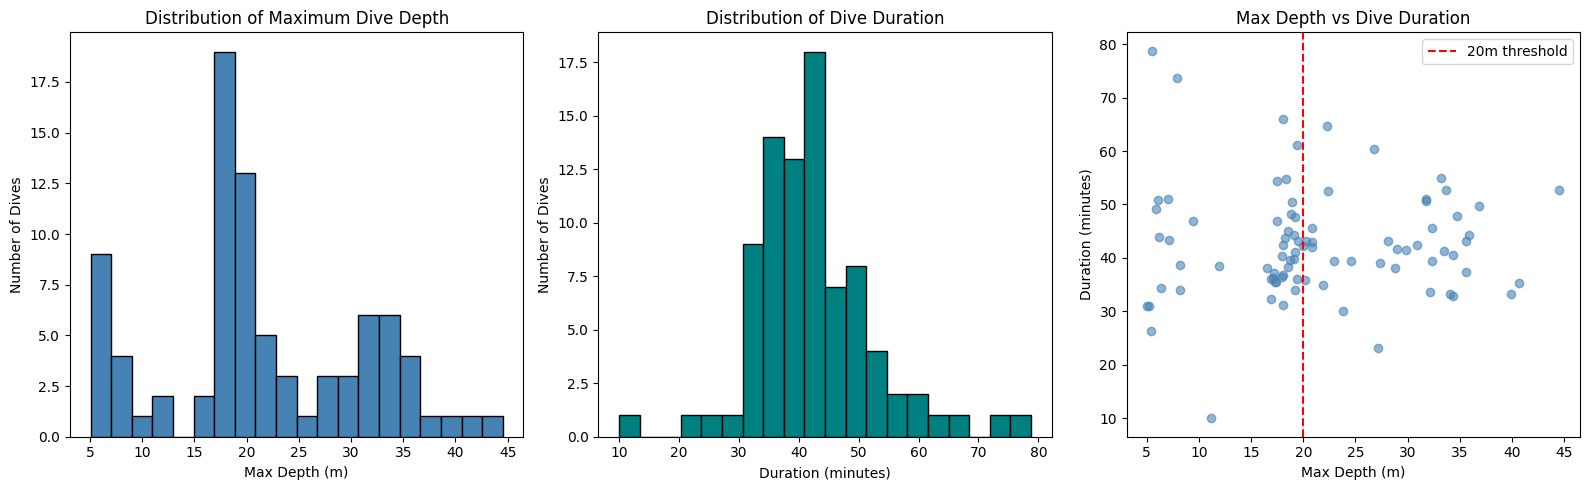

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Distribution of max depth
axes[0].hist(df_clean["max_depth"], bins=20, color="steelblue", edgecolor="black")
axes[0].set_xlabel("Max Depth (m)")
axes[0].set_ylabel("Number of Dives")
axes[0].set_title("Distribution of Maximum Dive Depth")

# 2. Distribution of duration
axes[1].hist(df_clean["duration_min"], bins=20, color="teal", edgecolor="black")
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("Number of Dives")
axes[1].set_title("Distribution of Dive Duration")

# 3. Depth vs Duration scatter plot
axes[2].scatter(df_clean["max_depth"], df_clean["duration_min"], alpha=0.6, color="steelblue")
axes[2].axvline(x=20, color="red", linestyle="--", label="20m threshold")
axes[2].set_xlabel("Max Depth (m)")
axes[2].set_ylabel("Duration (minutes)")
axes[2].set_title("Max Depth vs Dive Duration")
axes[2].legend()

plt.tight_layout()
plt.show()

## Hypothesis Testing

We test whether dive depth significantly affects dive duration using three statistical tests:

1. **Independent samples t-test** -> parametric test comparing mean duration between shallow (<20m) and deep (>=20m) dives
2. **Mann-Whitney U test** -> non-parametric equivalent, does not assume normality
3. **Spearman correlation** -> non-parametric ranked correlation between depth and duration

Significance level: α = 0.05

In [4]:
df_hyp = df_clean.dropna(subset=["max_depth", "duration_min"])

# Split into shallow and deep groups
shallow = df_hyp[df_hyp["max_depth"] < 20]["duration_min"]
deep = df_hyp[df_hyp["max_depth"] >= 20]["duration_min"]

print(f"Shallow dives (<20m): n={len(shallow)}, mean={shallow.mean():.1f} min, median={shallow.median():.1f} min")
print(f"Deep dives (>=20m):   n={len(deep)}, mean={deep.mean():.1f} min, median={deep.median():.1f} min")

# 1. T-test
t_stat, t_p = stats.ttest_ind(shallow, deep)
print(f"\n1. T-test: t={t_stat:.3f}, p-value={t_p:.4f}")

# 2. Mann-Whitney U test
u_stat, u_p = stats.mannwhitneyu(shallow, deep, alternative="two-sided")
print(f"2. Mann-Whitney U: U={u_stat:.1f}, p-value={u_p:.4f}")

# 3. Spearman correlation
spearman_r, spearman_p = stats.spearmanr(df_hyp["max_depth"], df_hyp["duration_min"])
print(f"3. Spearman r={spearman_r:.3f}, p-value={spearman_p:.4f}")

Shallow dives (<20m): n=47, mean=42.5 min, median=40.3 min
Deep dives (>=20m):   n=38, mean=42.6 min, median=41.9 min

1. T-test: t=-0.058, p-value=0.9540
2. Mann-Whitney U: U=847.0, p-value=0.6876
3. Spearman r=0.094, p-value=0.3938


## Results and Interpretation

All three hypothesis tests returned non-significant results (p > 0.05):

- **T-test:** t = -0.058, p = 0.954\
Significant difference in mean duration between shallow and deep dives
- **Mann-Whitney U:** U = 847.0, p = 0.688\
No significant difference in the distribution of durations between groups
- **Spearman correlation:** r = 0.094, p = 0.394\
No significant monotonic relationship between depth and duration

**Conclusion:** We fail to reject H0. The data do not support the hypothesis that deeper dives have shorter durations.

**Interpretation:** The mean duration of shallow dives (42.5 min) and deep dives (42.6 min) are virtually identical. This suggests that as an experienced diver and instructor, dive duration is planned consistently regardless of depth. Rather than being constrained by nitrogen loading limits, dives appear to be terminated by air consumption or planned dive time; both of which are managed consistently across all depths.

**Limitations:**
- Sample size of 85 dives may limit statistical power
- No air consumption data was available in the exported .fit files, preventing direct validation of the air efficiency assumption
- Dive site type and conditions were not controlled for, which may introduce confounding variability